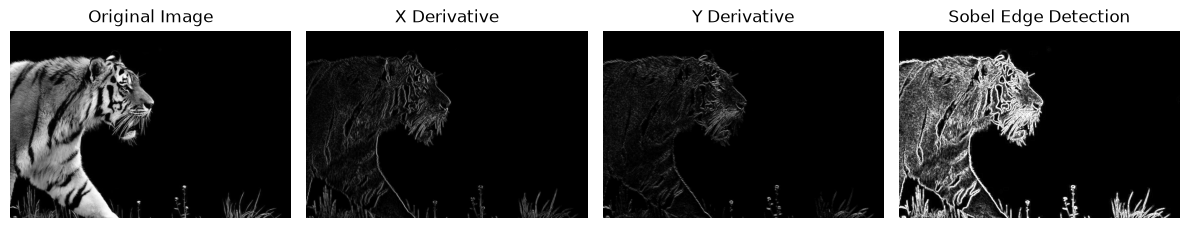

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read colour image
image = cv2.imread(r"D:\Sem-7\CV-LAB\image_exp5_tiger.png")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Sobel X Kernel
Gx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

# Sobel Y Kernel
Gy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

# Apply kernel manually
def apply_kernel(image, kernel):
    height, width = image.shape
    # Edge padding
    padded = np.pad(image, 1, mode="edge")
    output = np.zeros((height, width), dtype=float)
    
    # Apply convolution
    for i in range(height):
        for j in range(width):
            window = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(window * kernel)
            
    return output

# Calculate X and Y derivatives
Ix = apply_kernel(gray, Gx)
Iy = apply_kernel(gray, Gy)

# Calculate gradient magnitude
magnitude = np.sqrt(Ix**2 + Iy**2)

# Convert to displayable range
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(Ix), cmap="gray")
plt.title("X Derivative")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(Iy), cmap="gray")
plt.title("Y Derivative")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(magnitude, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()